In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def display(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img)

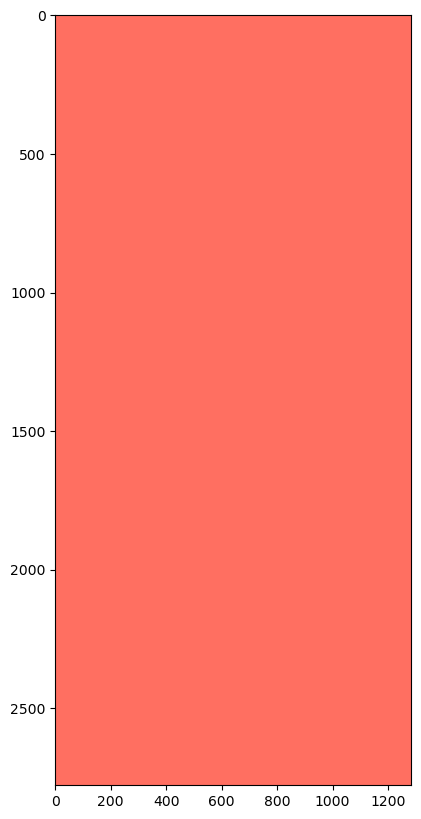

In [46]:
ff6f61 = cv2.imread('../DATA/color_detection/ff6f61.png')
ff6f61 = cv2.cvtColor(ff6f61, cv2.COLOR_BGR2RGB)
display(ff6f61)

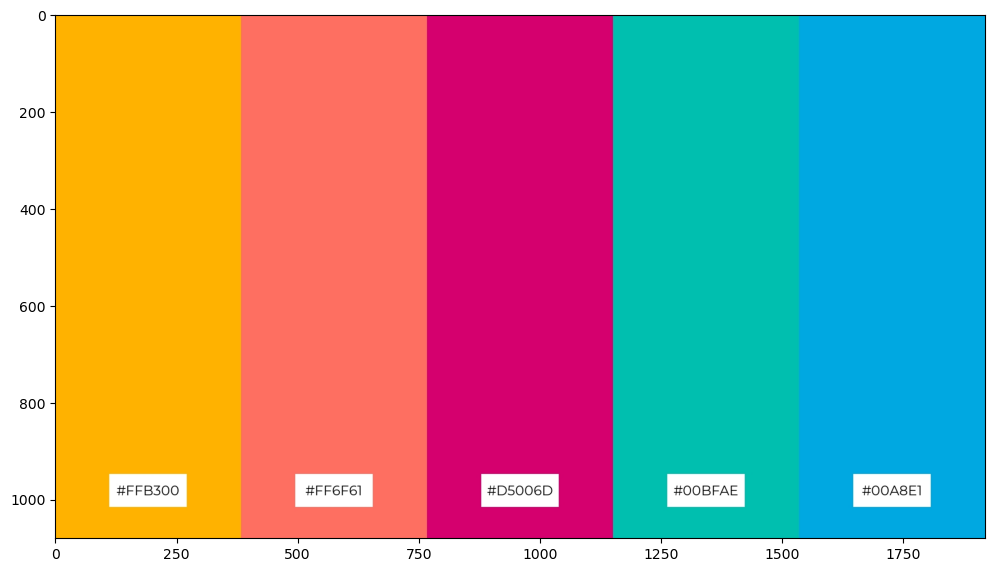

In [47]:
color_palette = cv2.imread('../DATA/color_detection/color_palette.jpg')
color_palette = cv2.cvtColor(color_palette, cv2.COLOR_BGR2RGB)
display(color_palette)

In [48]:
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(ff6f61, None)
kp2, des2 = sift.detectAndCompute(color_palette, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k = 2)

In [49]:
good  = []

for match1,match2 in matches:
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

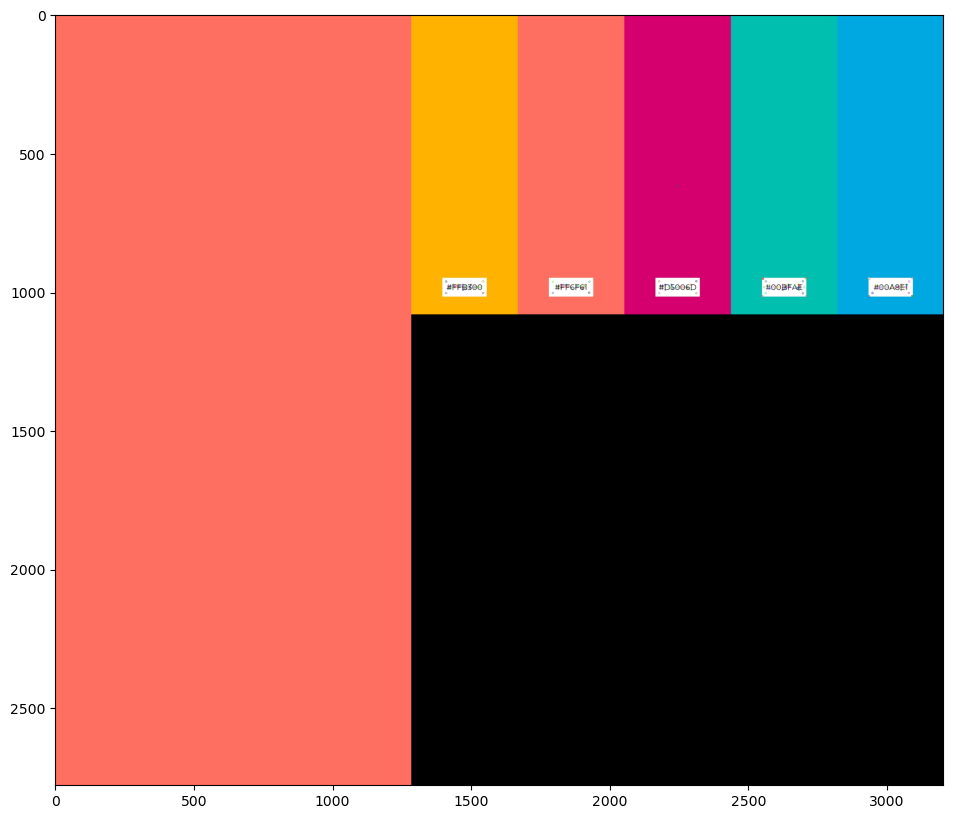

In [50]:
sift_matches = cv2.drawMatchesKnn(ff6f61, kp1, color_palette, kp2, good, None, 2)
display(sift_matches)

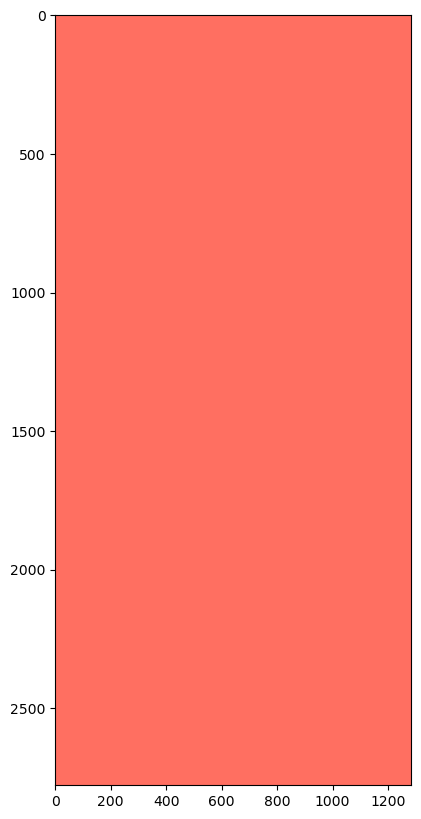

In [39]:
#Tamplate matching
ff6f61 = cv2.imread('../DATA/color_detection/ff6f61.png')
ff6f61 = cv2.cvtColor(ff6f61, cv2.COLOR_BGR2RGB)
display(ff6f61)

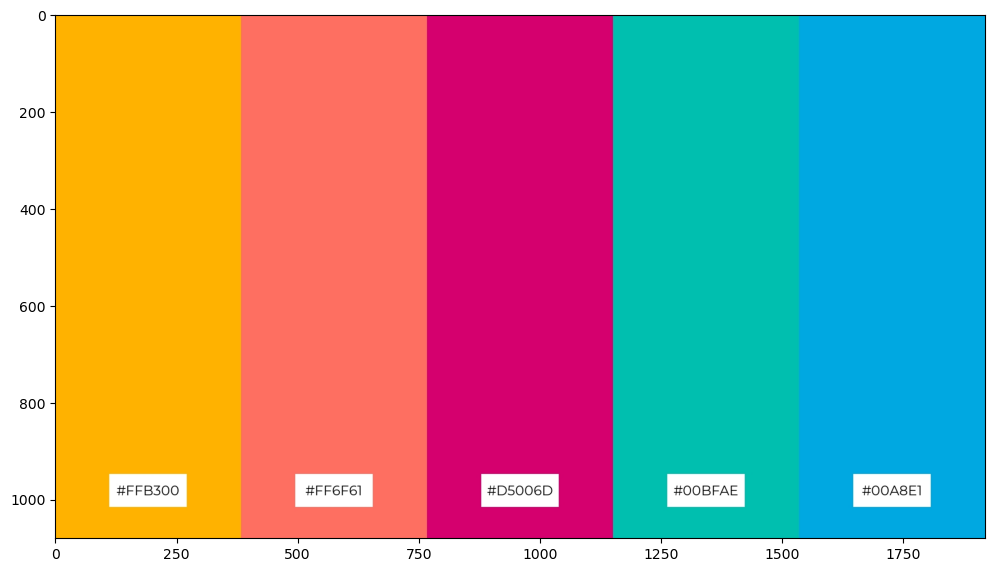

In [40]:
color_palette = cv2.imread('../DATA/color_detection/color_palette.jpg')
color_palette = cv2.cvtColor(color_palette, cv2.COLOR_BGR2RGB)
display(color_palette)

In [41]:
ff6f61.shape

(2778, 1284, 3)

In [42]:
color_palette.shape

(1080, 1920, 3)

In [43]:
print("Color Palette Shape:", color_palette.shape)
print("Template Shape:", ff6f61.shape)

Color Palette Shape: (1080, 1920, 3)
Template Shape: (2778, 1284, 3)


In [44]:
color_h, color_w, _ = color_palette.shape
template_h, template_w, _ = ff6f61.shape

# Ensure template is smaller than color_palette
if template_h > color_h or template_w > color_w:
    scale_factor = min(color_h / template_h, color_w / template_w)
    new_width = int(template_w * scale_factor)
    new_height = int(template_h * scale_factor)
    
    # Resize the template
    ff6f61_resized = cv2.resize(ff6f61, (new_width, new_height))
else:
    ff6f61_resized = ff6f61

print(f"Resized Template Shape: {ff6f61_resized.shape}")

Resized Template Shape: (1080, 499, 3)


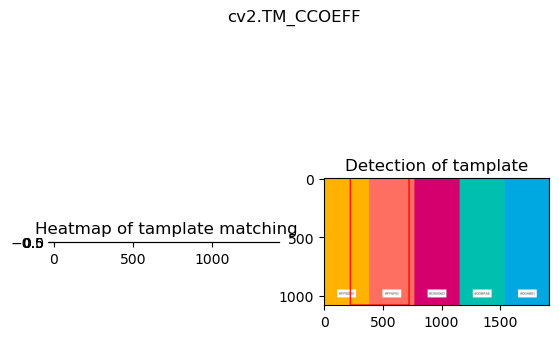

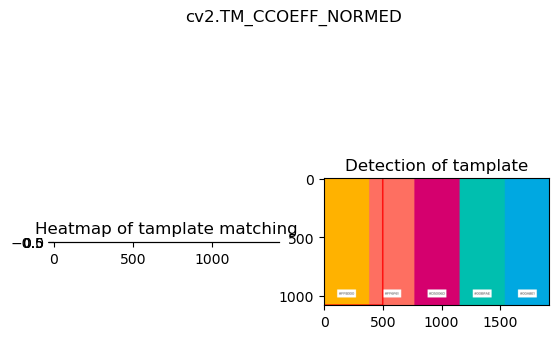

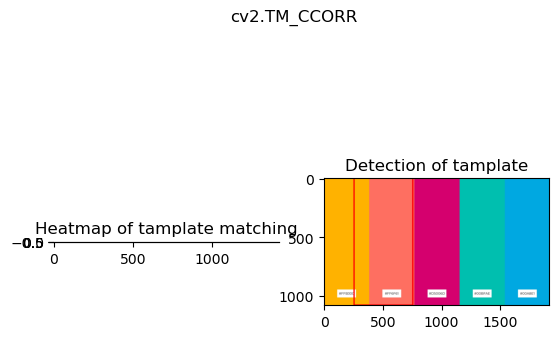

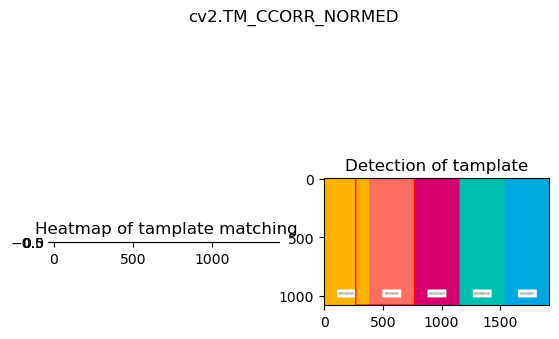

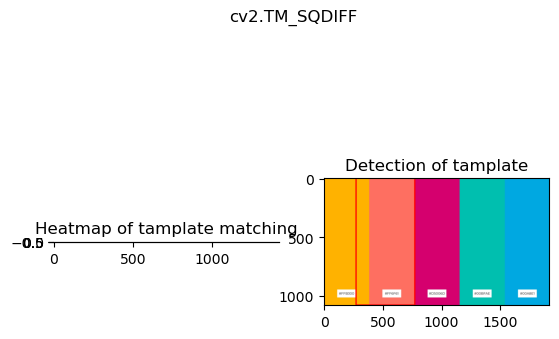

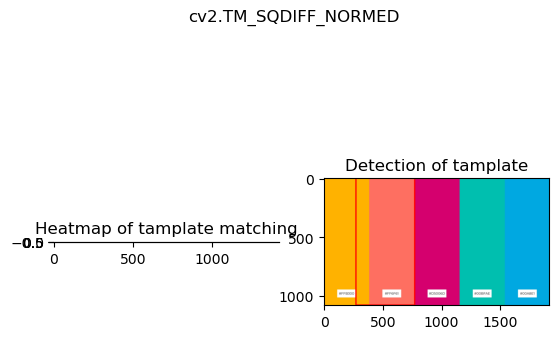

In [45]:
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR','cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']
my_method = eval('cv2.TM_CCOEFF')

color_palette_gray = cv2.cvtColor(color_palette, cv2.COLOR_BGR2GRAY) if len(color_palette.shape) == 3 else color_palette
ff6f61_gray = cv2.cvtColor(ff6f61_resized, cv2.COLOR_BGR2GRAY) if len(ff6f61_resized.shape) == 3 else ff6f61_resized

for m in methods:
    
    #Create the copy of image
    img_copy = color_palette.copy()
    
    method = eval(m)
    
    #Template matchin
    res = cv2.matchTemplate(img_copy, ff6f61_resized, method)
    
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
        
    height, width, color = ff6f61_resized.shape
    
    bot_right = (top_left[0] + width, top_left[1]+height)
    cv2.rectangle(img_copy, top_left, bot_right, (255,0,0), thickness=10)
    
    #Plot
    plt.subplot(121)
    res_norm = cv2.normalize(res, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    plt.imshow(res_norm, cmap='hot')
    plt.title('Heatmap of tamplate matching')
    
    plt.subplot(122)
    plt.imshow(img_copy)
    plt.title('Detection of tamplate')
    plt.suptitle(m)
    plt.show()
    